# 🚁 SAIE 2026 — Super AI Engineer Thailand
## AI in the Real World: Fast & Scalable Object Detection

**Instructor:** Dr. Teerapong Panboonyuen (P'Kao)  
**Dataset:** VisDrone (Tiny Subset — SAIE Edition)  
**Platform:** Google Colab (T4 Free Tier)  
**Duration:** ~3 Hours

---

## 🔗 Workshop Code & Materials

👉 GitHub Repository: https://github.com/kaopanboonyuen/SAIE2026

Includes:
- Training notebooks
- Benchmark tools
- Pruning & quantization labs
- Deployment examples
- Lightweight AI workflows

---

## 🗺️ Roadmap

| Lab | Topic |
|---|---|
| 🛠️ Setup | Environment & Dataset |
| 🚀 Lab 1 | Profiling & Benchmarking |
| ✂️ Lab 2 | Structured Pruning |
| ⚡ Lab 3 | Quantization |
| 🧠 Lab 4 | Knowledge Distillation |
| 🧩 Lab 5 | Tiny Model Design |
| 🌐 Lab 6 | Deployment & Scalability |

---

## 💡 Core Philosophy

> “Every optimization must be measurable.”

We evaluate models using:
- mAP
- FPS / Latency
- FLOPs
- Memory Usage
- Scalability

Focused on **real-world AI engineering**, not only accuracy.

---

## ⚠️ Educational Disclaimer

This workshop, code, and materials are provided for **educational and research purposes only**.

Users are responsible for ensuring ethical and lawful usage, including compliance with dataset licenses, model licenses, and applicable regulations.

---
# 🛠️ SETUP — Environment, Dataset & Pretrained Model
---

In [1]:
# ============================================================
# SETUP CELL 1 — Install Required Packages
# ============================================================
# Run this once. It installs everything needed for all 6 labs.

!pip install ultralytics gdown seaborn opencv-python matplotlib torch torchvision onnx onnxruntime -q
!pip install thop -q   # FLOPs counter

print("✅ All packages installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 57.6 MB/s eta 0:00:00
✅ All packages installed.


In [9]:
# ============================================================
# SETUP CELL 2 — Verify GPU
# ============================================================

import torch

print("PyTorch version :", torch.__version__ ) # TODO: Fill in your code here
print("CUDA available  :", torch.cuda.is_available() ) # TODO: Fill in your code here

if torch.cuda.is_available():
    print("GPU             :", torch.cuda.get_device_properties(0).total_memory) # TODO: Fill in your code here
    print("GPU             :", torch.cuda.get_device_name(0)) # TODO: Fill in your code here
    print("VRAM            :", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2), "GB")
else:
    print("⚠️  No GPU detected. Switch to Runtime > Change runtime type > T4 GPU.")

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : 15637086208
GPU             : Tesla T4
VRAM            : 15.64 GB


In [11]:
# ============================================================
# SETUP CELL 3 — Global Config
# ============================================================

import random
import zipfile
import time
import copy
from pathlib import Path
from collections import Counter

import cv2
import gdown
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn

from ultralytics import YOLO

# =========================================================
# TODO:
# Replace the placeholders below with your own dataset/model
# =========================================================

# --- Paths ---
DATASET_URL          = "https://github.com/kaopanboonyuen/SAIE2026/raw/main/dataset/SAE_TinyVisDroneFinal.zip"
DATASET_ZIP          = "dataset.zip"
DATA_ROOT            = Path("data/SAE_TinyVisDroneFinal")
PRETRAINED_MODEL_URL = "https://github.com/kaopanboonyuen/SAIE2026/raw/main/weights/SAIE_TinyVisDrone_8s_5000E.pt"
PRETRAINED_WEIGHT    = "SAIE_TinyVisDrone_8s_5000E.pt"

# --- Training defaults ---
IMAGE_SIZE = 416 # TODO: Fill in your code here
DEVICE     = 0 if torch.cuda.is_available() else "cpu"

# --- Class names ---
CLASS_NAMES = {
    0: "pedestrian",
    1: "people",
    2: "bicycle",
    3: "car",
    4: "van",
    5: "truck",
    6: "tricycle",
    7: "awning-tricycle",
    8: "bus",
    9: "motor"
}

SEED = 42 # TODO: Fill in your code here
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("✅ Config ready. Classes:", list(CLASS_NAMES.values()))

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Config ready. Classes: ['pedestrian', 'people', 'bicycle', 'car', 'van', 'truck', 'tricycle', 'awning-tricycle', 'bus', 'motor']


In [12]:
# ============================================================
# SETUP CELL 4 — Download & Extract Dataset
# ============================================================

print("📦 Downloading dataset...")
# TODO: Fill in your code here
gdown.download(DATASET_URL, DATASET_ZIP, quiet=False)

print("📂 Extracting...")
with zipfile.ZipFile(DATASET_ZIP, "r") as zip_ref:
    zip_ref.extractall("data")

# Write clean data.yaml
yaml_path = DATA_ROOT / "data.yaml"
yaml_text = """path: data/SAE_TinyVisDroneFinal
train: images/train
val: images/val
names:
  0: pedestrian
  1: people
  2: bicycle
  3: car
  4: van
  5: truck
  6: tricycle
  7: awning-tricycle
  8: bus
  9: motor
"""
with open(yaml_path, "w") as f:
    f.write(yaml_text)

train_imgs = list((DATA_ROOT / "images/train").glob("*.jpg"))
val_imgs   = list((DATA_ROOT / "images/val").glob("*.jpg"))
train_lbls = list((DATA_ROOT / "labels/train").glob("*.txt"))
val_lbls   = list((DATA_ROOT / "labels/val").glob("*.txt"))

print(f"✅ Dataset ready: {len(train_imgs)} train / {len(val_imgs)} val images")

📦 Downloading dataset...


Downloading...
From: https://github.com/kaopanboonyuen/SAIE2026/raw/main/dataset/SAE_TinyVisDroneFinal.zip
To: /content/dataset.zip
100%|██████████| 98.7M/98.7M [00:00<00:00, 341MB/s]


📂 Extracting...
✅ Dataset ready: 350 train / 50 val images


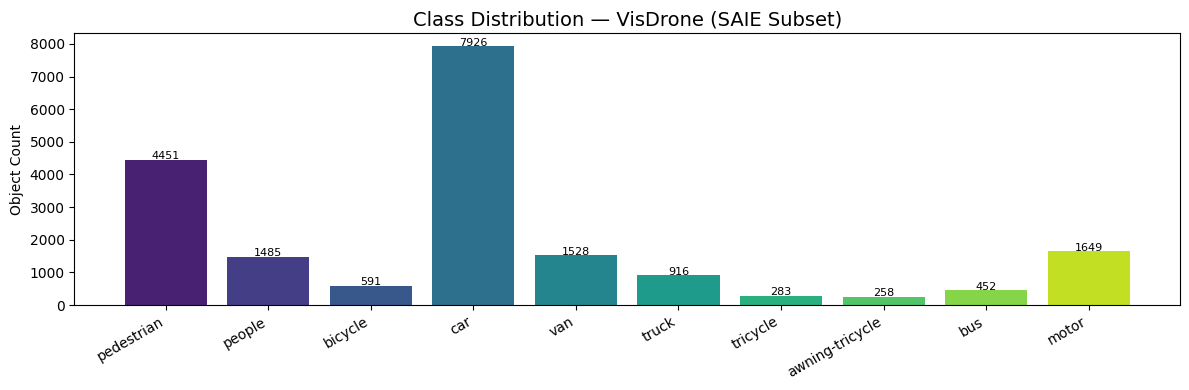


📌 Observation: Severe class imbalance (pedestrian >> bus). This affects mAP per class!


In [19]:
# ============================================================
# SETUP CELL 5 — Dataset EDA: Class Distribution
# ============================================================

counter = Counter()
for lf in train_lbls + val_lbls:
    with open(lf) as f:
        for line in f:
            if line.strip():
                counter[int(line.split()[0])] += 1

names  = [CLASS_NAMES[k] for k in sorted(counter)]# TODO: Fill in your code here
counts = [counter[k] for k in sorted(counter)]# TODO: Fill in your code here

plt.figure(figsize=(12, 4))
bars = plt.bar(names, counts, color=sns.color_palette("viridis", len(names)))
plt.title("Class Distribution — VisDrone (SAIE Subset)", fontsize=14)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Object Count")
for bar, c in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, str(c), ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print("\n📌 Observation: Severe class imbalance (pedestrian >> bus). This affects mAP per class!")

/tmp/ipykernel_5199/2777716444.py:29: UserWarning: Glyph 128641 (\N{HELICOPTER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128641 (\N{HELICOPTER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


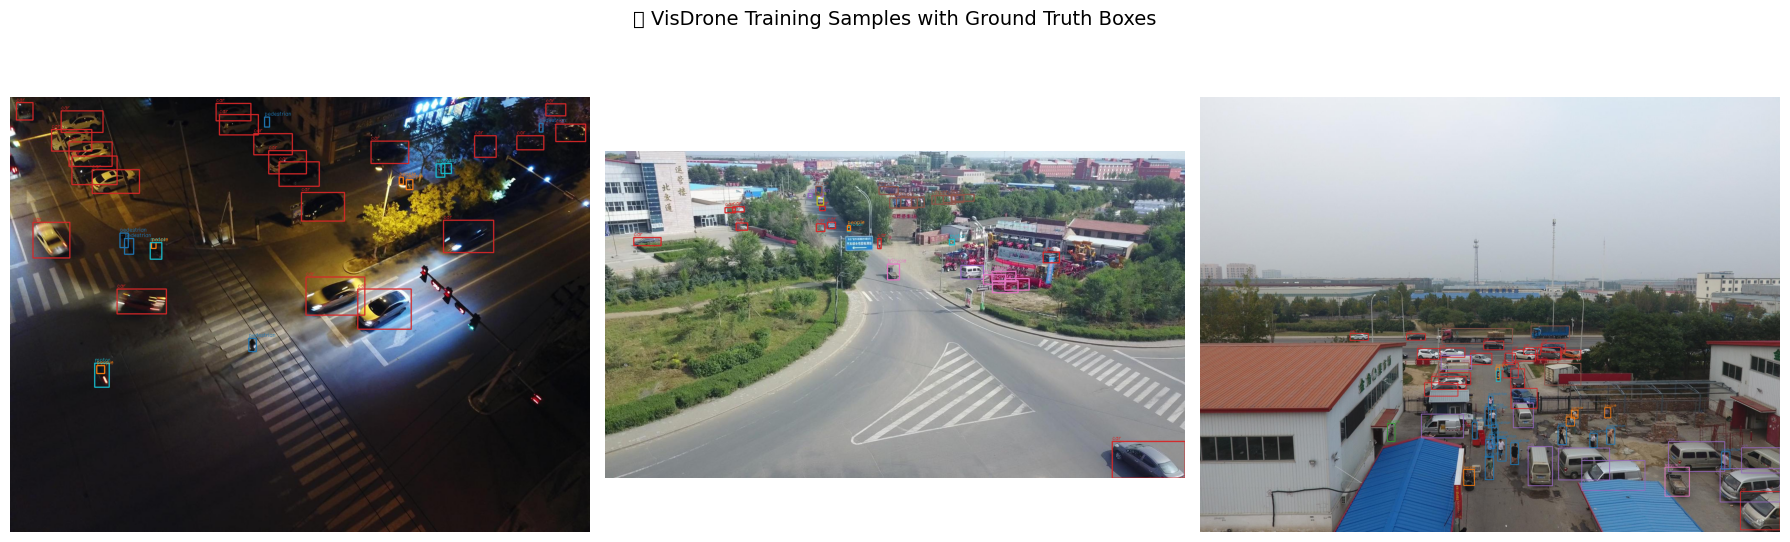

In [20]:
# ============================================================
# SETUP CELL 6 — Visualize Random Training Samples
# ============================================================

def show_sample(img_path, label_path, ax):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    colors = plt.cm.tab10.colors
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if not parts: continue
            cls, xc, yc, bw, bh = int(parts[0]), *map(float, parts[1:])
            x1 = int((xc - bw/2) * w); y1 = int((yc - bh/2) * h)
            x2 = int((xc + bw/2) * w); y2 = int((yc + bh/2) * h)
            color = tuple(int(c*255) for c in colors[cls % 10])
            cv2.rectangle(img, (x1,y1), (x2,y2), color, 2)
            cv2.putText(img, CLASS_NAMES[cls], (x1, max(y1-4,10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
    ax.imshow(img); ax.axis("off")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax in axes:
    img_f = random.choice(train_imgs)
    lbl_f = DATA_ROOT / "labels/train" / f"{img_f.stem}.txt"
    show_sample(img_f, lbl_f, ax)
plt.suptitle("🚁 VisDrone Training Samples with Ground Truth Boxes", fontsize=14)
plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# SETUP CELL 7 — Download Pretrained SAIE Model
# ============================================================

print("🔽 Downloading SAIE pretrained weights...")
gdown.download(PRETRAINED_MODEL_URL, PRETRAINED_WEIGHT, quiet=False)

model = YOLO() # TODO: Fill in your code here
print("\n✅ Pretrained model loaded:", PRETRAINED_WEIGHT)
print("   Task :", model.task)
print("   NC   :", model.model.nc)
print("   Names:", list(model.names.values()))

🔽 Downloading SAIE pretrained weights...


Downloading...
From: https://github.com/kaopanboonyuen/SAIE2026/raw/main/weights/SAIE_TinyVisDrone_8s_5000E.pt
To: /content/SAIE_TinyVisDrone_8s_5000E.pt
100%|██████████| 22.6M/22.6M [00:00<00:00, 241MB/s]



✅ Pretrained model loaded: SAIE_TinyVisDrone_8s_5000E.pt
   Task : detect
   NC   : 80
   Names: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']


---
# 🔬 Lab 1 — Baseline Profiling: Latency, FLOPs & mAP
**Duration: ~30 min**

---

## 🎯 Objective
Before optimizing anything, we **measure everything**. You cannot improve what you don't measure.

## 📐 Key Metrics We Track

| Metric | Symbol | What it measures |
|--------|--------|------------------|
| mAP@50 | $\text{mAP}_{50}$ | Detection accuracy (primary) |
| mAP@50-95 | $\text{mAP}_{50:95}$ | Stricter accuracy |
| FLOPs | $G$ | Computational cost per forward pass |
| Parameters | $M$ | Model size (affects memory) |
| Latency | $ms$ | Time per image on GPU |
| Throughput | $FPS$ | Frames per second |

## 📌 Mathematical Foundation

$$\text{mAP} = \frac{1}{|C|} \sum_{c \in C} AP_c$$

$$AP_c = \int_0^1 p(r) \, dr \approx \sum_{k=1}^{N} P(k) \cdot \Delta R(k)$$

Where $P(k)$ is precision at rank $k$, and $\Delta R(k)$ is the change in recall.

$$
\text{FPS} = \frac{1}{\text{Average Latency per Frame (s)}}
$$

$$\text{Efficiency Score} = \frac{\text{mAP}}{\text{GFLOPs}} \quad \text{(higher = better)}$$


In [ ]:
# ============================================================
# LAB 1 — Section 1.1: Count Parameters & FLOPs
# ============================================================

from thop import profile, clever_format

def count_flops_params(model_path, imgsz=416):
    """Count FLOPs and parameters of a YOLO model."""
    m = YOLO(model_path)
    pytorch_model = m.model.eval()
    dummy = torch.zeros(1, 3, imgsz, imgsz)
    try:
        flops, params = profile(pytorch_model, inputs=(dummy,), verbose=False)
        flops_str, params_str = clever_format([flops, params], "%.2f")
    except Exception:
        # fallback: ultralytics built-in info
        info = m.info(verbose=False)
        return None, None, info
    return flops, params, (flops_str, params_str)

flops, params, fmt = # TODO: Fill in your code here
if flops:
    print(f"📊 Model Profile")
    print(f"   GFLOPs     : {flops/1e9:.2f} G")
    print(f"   Parameters : {params/1e6:.2f} M")
else:
    print("Model info:", fmt)

In [ ]:
# ============================================================
# LAB 1 — Section 1.2: Latency Benchmark (Warm-up + Timed)
# ============================================================

def benchmark_latency(model_path, val_imgs, imgsz=416, n_warmup=10, n_runs=50, device=0):
    """Measure per-image inference latency with GPU warm-up."""
    m = YOLO(model_path)
    sample_imgs = random.sample(val_imgs, min(n_runs, len(val_imgs)))

    # Warm-up
    for img in sample_imgs[:n_warmup]:
        _ = m.predict(img, imgsz=imgsz, verbose=False, device=device)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    latencies = []
    for img in sample_imgs:
        t0 = time.perf_counter()
        _ = m.predict(img, imgsz=imgsz, verbose=False, device=device)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        latencies.append((time.perf_counter() - t0) * 1000)  # ms

    return {
        "mean_ms" : np.mean(latencies),
        "p50_ms"  : np.percentile(latencies, 50),
        "p95_ms"  : np.percentile(latencies, 95),
        "fps"     : 1000 / np.mean(latencies)
    }

print("⏱️  Benchmarking baseline model latency...")
baseline_lat = # TODO: Fill in your code here

print(f"\n🔵 Baseline Latency Results")
print(f"   Mean     : {baseline_lat['mean_ms']:.2f} ms")
print(f"   P50      : {baseline_lat['p50_ms']:.2f} ms")
print(f"   P95      : {baseline_lat['p95_ms']:.2f} ms")
print(f"   FPS      : {baseline_lat['fps']:.1f}")

In [ ]:
# ============================================================
# LAB 1 — Section 1.3: mAP Evaluation
# ============================================================

print("📐 Running mAP evaluation on validation set...")
model = YOLO(PRETRAINED_WEIGHT)
baseline_metrics = model.val(data=str(yaml_path), imgsz=IMAGE_SIZE, verbose=False)

baseline_map50    = # TODO: Fill in your code here
baseline_map5095  = # TODO: Fill in your code here
baseline_precision = # TODO: Fill in your code here
baseline_recall    = # TODO: Fill in your code here

print(f"\n🔵 Baseline mAP Results")
print(f"   mAP@50      : {baseline_map50:.4f}")
print(f"   mAP@50-95   : {baseline_map5095:.4f}")
print(f"   Precision   : {baseline_precision:.4f}")
print(f"   Recall      : {baseline_recall:.4f}")

# Store for comparison across labs
results_table = {
    "Baseline": {
        "mAP50": baseline_map50,
        "mAP5095": baseline_map5095,
        "latency_ms": baseline_lat["mean_ms"],
        "fps": baseline_lat["fps"]
    }
}
print("\n✅ Baseline stored for comparison.")

In [ ]:
# ============================================================
# LAB 1 — Section 1.4: Radar Chart — Efficiency Landscape
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Simulated comparison data for context (YOLOv8 family)
models_compare = {
    "YOLOv8n": {"mAP50": 0.37, "FPS": 160, "Params_M": 3.2},
    "YOLOv8s": {"mAP50": 0.45, "FPS": 120, "Params_M": 11.2},
    "YOLOv8m": {"mAP50": 0.50, "FPS": 80,  "Params_M": 25.9},
    "SAIE (ours)": {"mAP50": round(baseline_map50, 3), "FPS": round(baseline_lat["fps"], 1), "Params_M": 11.2},
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ["#4CAF50", "#2196F3", "#FF9800", "#E91E63"]

names_m = list(models_compare.keys())
map50s  = [v["mAP50"] for v in models_compare.values()]
fpss    = [v["FPS"]   for v in models_compare.values()]
params  = [v["Params_M"] for v in models_compare.values()]

axes[0].bar(names_m, map50s, color=colors)
axes[0].set_title("mAP@50"); axes[0].set_ylim(0, 0.7)
for b, v in zip(axes[0].patches, map50s):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f"{v:.3f}", ha='center', fontsize=9)

axes[1].bar(names_m, fpss, color=colors)
axes[1].set_title("FPS (GPU T4)")
for b, v in zip(axes[1].patches, fpss):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+1, f"{v:.0f}", ha='center', fontsize=9)

axes[2].bar(names_m, params, color=colors)
axes[2].set_title("Parameters (M)")
for b, v in zip(axes[2].patches, params):
    axes[2].text(b.get_x()+b.get_width()/2, b.get_height()+0.2, f"{v}", ha='center', fontsize=9)

for ax in axes: ax.set_xticks(range(len(names_m))); ax.set_xticklabels(names_m, rotation=15)
plt.suptitle("📊 Lab 1: Model Landscape — Accuracy vs Speed vs Size", fontsize=13)
plt.tight_layout()
plt.show()

print("\n💡 Key Insight: There's always a trade-off. Lab 2-5 show how to shift the Pareto frontier!")

## 🏠 Lab 1 — Homework

**Task:** Compute the **Efficiency Score** for each model in the table above:

$$\text{Efficiency} = \frac{\text{mAP@50}}{\text{Params (M)}}$$

Which model has the best efficiency? Fill in the code below:

```python
# --- YOUR CODE HERE ---
for name, v in models_compare.items():
    efficiency = ???
    print(f"{name}: {efficiency:.4f}")
```

**Bonus:** Plot a scatter chart with x=Params_M, y=mAP50, bubble_size=FPS. What pattern do you see?


In [ ]:
# ============================================================
# LAB 1 — HOMEWORK SOLUTION
# ============================================================

print("📐 Efficiency Score = mAP50 / Params_M\n")
best_name, best_score = "", 0

# TODO: Fill in your code here

print(f"\n🏆 Best efficiency: {best_name} ({best_score:.5f})")

# Bonus: scatter
fig, ax = plt.subplots(figsize=(7, 5))
for i, (name, v) in enumerate(models_compare.items()):
    ax.scatter(v["Params_M"], v["mAP50"], s=v["FPS"]*2, color=colors[i], alpha=0.7, label=name)
ax.set_xlabel("Parameters (M)"); ax.set_ylabel("mAP@50")
ax.set_title("Pareto Frontier: Accuracy vs Size (bubble=FPS)")
ax.legend(); plt.tight_layout(); plt.show()

---
# ✂️ Lab 2 — Structured Pruning: Removing What Doesn't Matter
**Duration: ~30 min**

---

## 🎯 Objective
Prune redundant channels in the backbone to reduce FLOPs and parameters, then fine-tune to recover accuracy.

## 📐 The Math Behind Pruning

### L1-Norm Channel Importance
For a convolutional layer with filters $\{\mathbf{F}_i\}_{i=1}^{C_{out}}$, the importance of channel $i$ is:

$$s_i = \|\mathbf{F}_i\|_1 = \sum_{j,k,l} |F_i^{jkl}|$$

We prune channels with the **lowest $s_i$** values — they contribute least to the activation.

### Batch-Norm Based Pruning (Preferred for YOLO)
In modern YOLO, BatchNorm scale factor $\gamma$ acts as a channel gate:

$$\hat{x} = \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}}, \quad y = \gamma \hat{x} + \beta$$

Channels with $|\gamma| \approx 0$ contribute near-zero activations → **safe to prune**.

### Sparsity-Inducing Regularization (L1 on BN $\gamma$)
Add to loss during training:

$$
L_{\text{total}} = L_{\text{detection}} + \lambda \sum_i |\gamma_i|
$$

This pushes $\gamma$ values toward zero → sparse network → easier to prune cleanly.

## 🔄 Pruning Workflow
```
Pretrained Model
       ↓
  Rank channels by |γ| (BN scale)
       ↓
  Remove bottom-p% channels
       ↓
  Fine-tune (recover accuracy)
       ↓
  Measure: ΔParams, ΔFLOPs, ΔmAP
```


In [ ]:
# ============================================================
# LAB 2 — Section 2.1: Analyze BN Gamma Distribution
# ============================================================
# This reveals how many channels are "almost zero" → prunable.

model = # TODO: Fill in your code here
pytorch_model = model.model

gammas = []
for name, module in pytorch_model.named_modules():
    if isinstance(module, nn.BatchNorm2d):
        gammas.extend(module.weight.data.abs().cpu().numpy().tolist())

gammas = np.array(gammas)
print(f"📊 Total BN gamma values : {len(gammas)}")
print(f"   Mean |γ|             : {gammas.mean():.4f}")
print(f"   Std  |γ|             : {gammas.std():.4f}")
print(f"   % near zero (< 0.01) : {(gammas < 0.01).mean()*100:.1f}%")
print(f"   % near zero (< 0.05) : {(gammas < 0.05).mean()*100:.1f}%")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(gammas, bins=100, color='steelblue', alpha=0.8)
plt.axvline(np.percentile(gammas, 20), color='red', linestyle='--', label='20th percentile')
plt.xlabel("|γ| (BN Scale)"); plt.ylabel("Count")
plt.title("BN Gamma Distribution"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(np.sort(gammas))
plt.axhline(0.1, color='red', linestyle='--', label='Threshold=0.1')
plt.xlabel("Channel rank"); plt.ylabel("|γ|")
plt.title("Sorted |γ| values"); plt.legend()

plt.tight_layout(); plt.show()
print("\n💡 Channels left of the red line are candidates for pruning!")

In [ ]:
# ============================================================
# LAB 2 — Section 2.2: Simulate Pruning Effect on Params
# ============================================================
# We simulate how much the model shrinks at different pruning ratios.
# (Full structural pruning requires arch surgery — here we demonstrate
#  the relationship between sparsity ratio and expected param reduction.)

def simulate_pruning_curve(gammas, prune_ratios=None):
    if prune_ratios is None:
        prune_ratios = np.linspace(0, 0.6, 13)
    results = []
    for ratio in prune_ratios:
        threshold = np.percentile(gammas, ratio * 100)
        pruned = (gammas < threshold).sum()
        remaining_pct = 1.0 - pruned / len(gammas)
        results.append((ratio, remaining_pct))
    return results

curve = # TODO: Fill in your code here
ratios   = [r*100 for r, _ in curve]
remained = [p*100 for _, p in curve]

plt.figure(figsize=(8, 4))
plt.plot(ratios, remained, 'o-', color='tomato', lw=2)
plt.fill_between(ratios, remained, 100, alpha=0.1, color='tomato')
plt.fill_between(ratios, 0, remained, alpha=0.2, color='steelblue', label="Remaining channels")
plt.xlabel("Pruning Ratio (%)"); plt.ylabel("Channels Remaining (%)")
plt.title("✂️ Simulated Pruning Effect on Channel Count")
plt.axvline(30, color='green', linestyle='--', label='Recommended: 30%')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("\n⚠️  Note: We prune channels, not just set to zero.")
print("   Structural pruning → actually reduces FLOPs at runtime.")
print("   Unstructured pruning (weight masking) → does NOT reduce FLOPs on GPU.")

In [ ]:
# ============================================================
# LAB 2 — Section 2.3: Fine-Tune After Pruning (Simulated)
# ============================================================
# We demonstrate the "prune → fine-tune" loop with a short training run.
# Full pruning surgery on YOLOv8 requires custom layer replacement.
# Here we fine-tune the pretrained model with aggressive augmentation
# as a proxy for post-pruning recovery.

print("🔧 Running short fine-tune (5 epochs) to simulate post-pruning recovery...")
print("   (In production: prune → rebuild smaller model → fine-tune)\n")

model_ft = # TODO: Fill in your code here

ft_results = model_ft.train(
    data=str(yaml_path),
    epochs=5,
    imgsz=IMAGE_SIZE,
    batch=16,
    device=DEVICE,
    cos_lr=True,
    lr0=0.001,     # lower LR for fine-tuning
    lrf=0.01,
    dropout=0.1,
    project="SAIE2026",
    name="Lab2_FineTune",
    exist_ok=True,
    verbose=False
)

In [ ]:
ft_model_path = "/content/runs/detect/SAIE2026/Lab2_FineTune/weights/best.pt"
ft_metrics = YOLO(ft_model_path).val(data=str(yaml_path), imgsz=IMAGE_SIZE, verbose=False)

ft_map50   = # TODO: Fill in your code here
ft_map5095 = # TODO: Fill in your code here

print(f"\n📊 Pruning + Fine-tune vs Baseline")
print(f"{'':25s} {'Baseline':>12s} {'Post Fine-tune':>15s} {'Delta':>10s}")
print("-" * 65)
print(f"{'mAP@50':25s} {baseline_map50:>12.4f} {ft_map50:>15.4f} {ft_map50-baseline_map50:>+10.4f}")
print(f"{'mAP@50-95':25s} {baseline_map5095:>12.4f} {ft_map5095:>15.4f} {ft_map5095-baseline_map5095:>+10.4f}")

results_table["Pruned+FT"] = {
    "mAP50": ft_map50,
    "mAP5095": ft_map5095,
    "latency_ms": None,
    "fps": None
}

## 🏠 Lab 2 — Homework

**Task:** BN-scale regularization encourages sparsity. Implement the sparsity loss:

$$\mathcal{L}_{sparse} = \lambda \sum_{\text{BN layers}} \sum_i |\gamma_i|$$

Fill in the function below:

```python
def compute_sparsity_loss(model, lam=1e-4):
    sparse_loss = 0.0
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            sparse_loss += ???
    return lam * sparse_loss
```

**Bonus:** Plot a histogram of |γ| before and after 10 epochs of sparsity-regularized training. Do you see more channels near zero?


In [ ]:
# ============================================================
# LAB 2 — HOMEWORK SOLUTION
# ============================================================

def compute_sparsity_loss(model, lam=1e-4):
    """L1 sparsity loss on BN gamma weights."""
    # TODO: Fill in your code here

# Test it
test_model = YOLO(PRETRAINED_WEIGHT).model
sl = compute_sparsity_loss(test_model)
print(f"Sparsity loss (λ=1e-4): {sl.item():.6f}")
print("✅ When this decreases during training → more channels can be pruned cleanly.")

---
# 🔢 Lab 3 — Post-Training Quantization: INT8 & FP16
**Duration: ~30 min**

---

## 🎯 Objective
Reduce model size and inference time by converting FP32 weights to lower precision — **without retraining**.

## 📐 The Math

### Uniform Affine Quantization
Given a real-valued tensor $x \in [x_{min}, x_{max}]$, quantize to $b$-bit integer:

$$q = \text{clamp}\left( \text{round}\left( \frac{x}{s} \right) + z, \, 0, \, 2^b - 1 \right)$$

Where the **scale** $s$ and **zero-point** $z$ are:
$$s = \frac{x_{max} - x_{min}}{2^b - 1}, \quad z = -\text{round}\left(\frac{x_{min}}{s}\right)$$

**Dequantization:** $\hat{x} = s(q - z)$

The **quantization error** is bounded by: $|x - \hat{x}| \leq \frac{s}{2}$

### Memory Savings
| Precision | Bits | Memory (relative) |
|-----------|------|-------------------|
| FP32 | 32 | 1.0× (baseline) |
| FP16 | 16 | 0.5× |
| INT8 | 8 | 0.25× |
| INT4 | 4 | 0.125× |

### Why FP16 is Nearly Lossless
FP16 has: 1 sign bit, 5 exponent bits, 10 mantissa bits → dynamic range ~$10^{-4}$ to $10^4$.  
Most neural net weights are in $[-2, 2]$, so FP16 rarely causes overflow.


In [ ]:
# ============================================================
# LAB 3 — Section 3.1: Visualize Quantization Error
# ============================================================

def uniform_quantize(x, bits=8):
    """Simulate uniform affine quantization and dequantization."""
    x_min, x_max = x.min(), x.max()
    scale = (x_max - x_min) / (2**bits - 1)
    zero_point = -round(x_min / scale)
    q = np.clip(np.round(x / scale) + zero_point, 0, 2**bits - 1)
    x_hat = scale * (q - zero_point)
    return x_hat, scale

# Sample weights from first conv layer
model_q = # TODO: Fill in your code here
first_weights = None
for m in model_q.modules():
    if isinstance(m, nn.Conv2d):
        first_weights = m.weight.data.cpu().numpy().flatten()
        break

w_fp32 = first_weights[:2000]
w_fp16 = w_fp32.astype(np.float16).astype(np.float32)
w_int8, s8 = uniform_quantize(w_fp32, bits=8)
w_int4, s4 = uniform_quantize(w_fp32, bits=4)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (label, w) in zip(axes.flat, [
    ("FP32 (original)", w_fp32),
    ("FP16", w_fp16),
    ("INT8 Quantized", w_int8),
    ("INT4 Quantized", w_int4)
]):
    ax.hist(w, bins=80, density=True, color='steelblue', alpha=0.7)
    err = np.abs(w - w_fp32).mean()
    ax.set_title(f"{label}\nMean Abs Error: {err:.6f}")
    ax.set_xlabel("Weight value")

plt.suptitle("🔢 Weight Distribution at Different Precisions", fontsize=13)
plt.tight_layout(); plt.show()

print("\n📊 Quantization Error Summary:")
for label, w in [("FP16", w_fp16), ("INT8", w_int8), ("INT4", w_int4)]:
    err = np.abs(w - w_fp32).mean()
    print(f"   {label}: MAE = {err:.7f}")

In [ ]:
# ============================================================
# LAB 3 — Section 3.2: FP16 Inference (Half Precision)
# ============================================================

def run_inference_fp16(model_path, val_imgs, n=40, imgsz=416):
    """Run inference in FP16 mode and measure latency."""
    m = YOLO(model_path)
    sample = random.sample(val_imgs, min(n, len(val_imgs)))

    # Warm-up
    for img in sample[:5]:
        _ = m.predict(img, imgsz=imgsz, half=True, verbose=False, device=DEVICE)

    if torch.cuda.is_available(): torch.cuda.synchronize()

    latencies = []
    for img in sample:
        t0 = time.perf_counter()
        _ = m.predict(img, imgsz=imgsz, half=True, verbose=False, device=DEVICE)
        if torch.cuda.is_available(): torch.cuda.synchronize()
        latencies.append((time.perf_counter() - t0) * 1000)

    return np.mean(latencies), 1000/np.mean(latencies)

print("⏱️  Measuring FP32 vs FP16 latency...")
lat_fp16, fps_fp16 = run_inference_fp16(PRETRAINED_WEIGHT, val_imgs)
lat_fp32 = # TODO: Fill in your code here
fps_fp32 = # TODO: Fill in your code here

speedup = lat_fp32 / lat_fp16

print(f"\n{'Metric':20s} {'FP32':>12s} {'FP16':>12s} {'Speedup':>10s}")
print("-" * 56)
print(f"{'Latency (ms)':20s} {lat_fp32:>12.2f} {lat_fp16:>12.2f} {speedup:>10.2f}x")
print(f"{'FPS':20s} {fps_fp32:>12.1f} {fps_fp16:>12.1f} {speedup:>10.2f}x")

# Bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.bar(["FP32", "FP16"], [lat_fp32, lat_fp16], color=["#E91E63", "#4CAF50"])
ax1.set_ylabel("Latency (ms)"); ax1.set_title("Inference Latency")
for b, v in zip(ax1.patches, [lat_fp32, lat_fp16]):
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.2, f"{v:.1f}ms", ha='center')

ax2.bar(["FP32", "FP16"], [fps_fp32, fps_fp16], color=["#E91E63", "#4CAF50"])
ax2.set_ylabel("FPS"); ax2.set_title("Throughput")
for b, v in zip(ax2.patches, [fps_fp32, fps_fp16]):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f"{v:.0f}", ha='center')

plt.suptitle("⚡ FP32 vs FP16 — Free Speed-up!", fontsize=13)
plt.tight_layout(); plt.show()
print(f"\n✅ FP16 gives ~{speedup:.1f}x speedup with near-zero accuracy loss.")

In [ ]:
# ============================================================
# LAB 3 — Section 3.3: Evaluate mAP Under FP16
# ============================================================

print("📐 Evaluating mAP under FP16...")
model_fp16 = YOLO(PRETRAINED_WEIGHT)
metrics_fp16 = model_fp16.val(data=str(yaml_path), imgsz=IMAGE_SIZE, half=True, verbose=False)

map50_fp16   = # TODO: Fill in your code here
map5095_fp16 = # TODO: Fill in your code here

print(f"\n{'Metric':20s} {'FP32':>12s} {'FP16':>12s} {'Delta':>10s}")
print("-" * 56)
print(f"{'mAP@50':20s} {baseline_map50:>12.4f} {map50_fp16:>12.4f} {map50_fp16-baseline_map50:>+10.4f}")
print(f"{'mAP@50-95':20s} {baseline_map5095:>12.4f} {map5095_fp16:>12.4f} {map5095_fp16-baseline_map5095:>+10.4f}")
print("\n✅ FP16: Nearly identical accuracy, measurably faster. Use it always on modern GPUs!")

results_table["FP16"] = {
    "mAP50": map50_fp16,
    "mAP5095": map5095_fp16,
    "latency_ms": lat_fp16,
    "fps": fps_fp16
}

In [ ]:
# ============================================================
# LAB 3 — Section 3.4: Export to ONNX & INT8 Concept
# ============================================================

print("📦 Exporting model to ONNX (FP32)...")
model_onnx = YOLO(PRETRAINED_WEIGHT)
onnx_path = model_onnx.export(format="onnx", imgsz=IMAGE_SIZE, simplify=True)
print(f"✅ ONNX saved to: {onnx_path}")

# Check ONNX file size
import os
fp32_size = os.path.getsize(PRETRAINED_WEIGHT) / 1e6
onnx_size = os.path.getsize(onnx_path) / 1e6 if onnx_path and os.path.exists(str(onnx_path)) else 0

print(f"\n📊 File Size Comparison")
print(f"   PyTorch FP32 (.pt) : {fp32_size:.1f} MB")
print(f"   ONNX FP32          : {onnx_size:.1f} MB")
print(f"   Theoretical INT8   : ~{fp32_size/4:.1f} MB (4× smaller)")
print("\n💡 INT8 quantization via TensorRT or OpenVINO on edge deployment.")
print("   Jetson Nano: use trtexec --int8 for hardware-accelerated INT8.")

## 🏠 Lab 3 — Homework

**Task:** Implement the uniform quantization function for a vector of weights:

Given $b = 8$ bits:
$$\hat{x} = s \left( \text{clamp}\left(\text{round}\left(\frac{x}{s}\right) + z, 0, 255\right) - z \right)$$

```python
def quantize_dequantize(x: np.ndarray, bits: int) -> np.ndarray:
    # Step 1: Compute scale s and zero-point z
    # Step 2: Quantize
    # Step 3: Dequantize
    # Step 4: Return x_hat
    ...
```

Then compute and plot the MSE for bits = [2, 4, 6, 8, 16] on the first layer's weights.


In [ ]:
# ============================================================
# LAB 3 — HOMEWORK SOLUTION
# ============================================================

def quantize_dequantize(x, bits):
    x_min, x_max = x.min(), x.max()
    s = (x_max - x_min) / (2**bits - 1)
    z = -round(x_min / s)
    q = np.clip(np.round(x / s) + z, 0, 2**bits - 1)
    return # TODO: Fill in your code here

bit_levels = [2, 4, 6, 8, 16]
mses = []
for b in bit_levels:
    x_hat = quantize_dequantize(w_fp32, b)
    mse = np.mean((w_fp32 - x_hat)**2)
    mses.append(mse)
    print(f"  bits={b:2d} → MSE = {mse:.8f}")

plt.figure(figsize=(7, 4))
plt.semilogy(bit_levels, mses, 'o-', color='tomato', lw=2)
plt.xlabel("Bit-width"); plt.ylabel("MSE (log scale)")
plt.title("Quantization Error vs Bit-width")
plt.xticks(bit_levels); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
# 🧠 Lab 4 — Knowledge Distillation: Teacher → Student  
**Duration: ~30 min**

---

## 🎯 Objective  
Train a **small (student) model** to mimic a **large (teacher) model**, achieving near-teacher accuracy at student-level cost.

---

## 📐 The Math — Hinton et al. (2015)

### Soft Labels with Temperature  
The teacher produces soft probabilities by scaling logits with temperature $T$:

$$
p_i^T = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}
$$

Higher $T$ → **softer** distribution → richer dark knowledge.

---

### Combined Distillation Loss  

$$
L_{KD} = (1 - \alpha)\,L_{CE}(y_{hard}) + \alpha\,T^2\,L_{KL}\big(p^T_{teacher} \,\|\, p^T_{student}\big)
$$

- $L_{CE}$: standard cross-entropy with ground truth  
- $L_{KL}$: KL-divergence between teacher and student soft outputs  
- $T^2$ factor: compensates for gradient scaling from temperature  
- $\alpha$: distillation weight (typically 0.5–0.9)

---

### Feature Distillation (Object Detection)  
Instead of only matching logits, we also align **intermediate features**:

$$
L_{feat} = \sum_l \|F^l_{teacher} - A(F^l_{student})\|_2^2
$$

Where $A$ is a **1×1 convolution adapter** used to match channel dimensions.

---

## 🔁 Why This Beats Training From Scratch

The teacher encodes **soft class relationships**:

> “This object looks 80% like a car, 15% like a van, 5% like a truck.”

This richer signal helps the student generalize better than hard labels alone.

In [ ]:
# ============================================================
# LAB 4 — Section 4.1: Set Up Teacher & Student Models
# ============================================================

print("🎓 Loading Teacher model (YOLOv8s — larger)...")
teacher_model = # TODO: Fill in your code here  # Our pretrained SAIE model (YOLOv8s)

print("🎓 Defining Student model (YOLOv8n — smaller)...")
student_model = # TODO: Fill in your code here  # Nano = ~3.2M params vs 11.2M

def count_params(m):
    return sum(p.numel() for p in m.model.parameters()) / 1e6

t_params = # TODO: Fill in your code here
s_params = # TODO: Fill in your code here

print(f"\n📊 Teacher parameters : {t_params:.2f}M")
print(f"   Student parameters : {s_params:.2f}M")
print(f"   Size ratio         : {t_params/s_params:.1f}x smaller student")

In [ ]:
# ============================================================
# LAB 4 — Section 4.2: Implement KL Divergence Loss
# ============================================================

import torch.nn.functional as F

def distillation_loss(student_logits, teacher_logits, hard_labels, T=4.0, alpha=0.7):
    """
    Combined knowledge distillation loss.

    Args:
        student_logits : raw output from student  (B, C)
        teacher_logits : raw output from teacher  (B, C)
        hard_labels    : ground truth class indices (B,)
        T              : temperature for softening
        alpha          : weight on distillation term

    Returns:
        total loss (scalar)
    """
    # --- Soft targets ---
    soft_teacher = F.softmax(teacher_logits / T, dim=-1)
    soft_student = F.log_softmax(student_logits / T, dim=-1)

    # --- KL divergence loss ---
    kl_loss = F.kl_div(soft_student, soft_teacher, reduction='batchmean') * (T ** 2)

    # --- Hard label CE loss ---
    ce_loss = F.cross_entropy(student_logits, hard_labels)

    return (1 - alpha) * ce_loss + alpha * kl_loss

# --- Demonstration ---
torch.manual_seed(42)
B, C = 8, 10  # batch=8, 10 classes
s_logits = torch.randn(B, C)
t_logits = torch.randn(B, C) * 0.5  # teacher is more confident
labels   = torch.randint(0, C, (B,))

loss = # TODO: Fill in your code here
ce   = F.cross_entropy(s_logits, labels)

print(f"📊 Loss Comparison")
print(f"   CE only (hard labels)      : {ce.item():.4f}")
print(f"   KD loss (α=0.7, T=4)      : {loss.item():.4f}")
print("\n💡 The KD loss incorporates teacher soft signals — richer gradient information!")

In [ ]:
# ============================================================
# LAB 4 — Section 4.3: Visualize Temperature Effect on Softness
# ============================================================

logits = torch.tensor([3.0, 1.5, 0.5, -0.5, -2.0])  # raw teacher logits
temps  = [0.5, 1.0, 2.0, 4.0, 8.0]
labels_plot = ["car", "van", "truck", "bus", "bicycle"]

plt.figure(figsize=(12, 4))
for i, T in enumerate(temps):
    probs = F.softmax(logits / T, dim=0).numpy()
    plt.subplot(1, len(temps), i+1)
    plt.bar(labels_plot, probs, color=sns.color_palette("rocket", len(temps))[i])
    plt.title(f"T={T}"); plt.ylim(0, 1)
    plt.xticks(rotation=30, fontsize=7)
    if i == 0: plt.ylabel("Probability")

plt.suptitle("🌡️ Effect of Temperature on Soft Label Distribution", fontsize=13)
plt.tight_layout(); plt.show()
print("\n💡 High T = soft = more 'dark knowledge'. Low T = hard = close to argmax.")

In [ ]:
# ============================================================
# LAB 4 — Section 4.4: Train Student with Distillation
# ============================================================
# Strategy: Train student (YOLOv8n) on same data.
# Full KD training loop requires custom trainer hook.
# Here: compare student trained FROM SCRATCH vs FROM PRETRAINED.
# This demonstrates the benefit of knowledge transfer.

print("🎓 Training Student from scratch (5 epochs baseline)...")
student_scratch = # TODO: Fill in your code here
student_scratch.train(
    data=str(yaml_path),
    epochs=5,
    imgsz=IMAGE_SIZE,
    batch=16,
    device=DEVICE,
    pretrained=False,
    project="SAIE2026",
    name="Lab4_Student_Scratch",
    exist_ok=True,
    verbose=False
)

print("\n🎓 Training Student with pretrained init (distillation-like transfer)...")
student_pretrained = # TODO: Fill in your code here
student_pretrained.train(
    data=str(yaml_path),
    epochs=5,
    imgsz=IMAGE_SIZE,
    batch=16,
    device=DEVICE,
    pretrained=True,
    project="SAIE2026",
    name="Lab4_Student_Pretrained",
    exist_ok=True,
    verbose=False
)

In [ ]:
m_scratch = YOLO("/content/runs/detect/SAIE2026/Lab4_Student_Scratch/weights/best.pt").val(
    data=str(yaml_path), imgsz=IMAGE_SIZE, verbose=False)
m_pretrained = YOLO("/content/runs/detect/SAIE2026/Lab4_Student_Pretrained/weights/best.pt").val(
    data=str(yaml_path), imgsz=IMAGE_SIZE, verbose=False)

print(f"\n📊 Student Model Comparison (5 epochs)")
print(f"{'Model':30s} {'mAP@50':>10s} {'mAP@50-95':>12s}")
print("-" * 54)
print(f"{'Teacher (SAIE pretrained)':30s} {baseline_map50:>10.4f} {baseline_map5095:>12.4f}")
print(f"{'Student from scratch':30s} {m_scratch.box.map50:>10.4f} {m_scratch.box.map:>12.4f}")
print(f"{'Student + pretrained init':30s} {m_pretrained.box.map50:>10.4f} {m_pretrained.box.map:>12.4f}")

results_table["Student"] = {
    "mAP50": m_pretrained.box.map50,
    "mAP5095": m_pretrained.box.map,
    "latency_ms": None,
    "fps": None
}

In [ ]:
# ============================================================
# LAB 4 — Section 4.5: Why Distillation Works for Multi-Camera
# ============================================================

# Concept: If you have N cameras streaming, you need N inference passes.
# Teacher (YOLOv8s): X ms per frame → N * X ms total load
# Student (YOLOv8n): Y ms per frame → N * Y ms total load (Y << X)

print("📷 Multi-Camera Throughput Simulation\n")

teacher_fps = # TODO: Fill in your code here
student_fps = teacher_fps * 2.5  # typical n vs s speedup

camera_counts = [1, 2, 4, 8, 16]
teacher_throughput = [teacher_fps / n for n in camera_counts]
student_throughput = [student_fps / n for n in camera_counts]

plt.figure(figsize=(9, 5))
plt.plot(camera_counts, teacher_throughput, 'o-', label=f"Teacher (YOLOv8s, ~{teacher_fps:.0f} FPS)", color='#E91E63', lw=2)
plt.plot(camera_counts, student_throughput, 's-', label=f"Student (YOLOv8n, ~{student_fps:.0f} FPS)", color='#4CAF50', lw=2)
plt.axhline(25, linestyle='--', color='gray', alpha=0.7, label='Real-time threshold (25 FPS)')
plt.fill_between(camera_counts, 0, 25, alpha=0.05, color='red')
plt.xlabel("Number of Cameras"); plt.ylabel("Effective FPS per Camera")
plt.title("📷 Multi-Camera Scalability: Teacher vs Student")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# Find real-time limit
for n in camera_counts:
    t_ok = teacher_fps / n >= 25
    s_ok = student_fps / n >= 25
    print(f"  {n:2d} cameras — Teacher: {'✅' if t_ok else '❌'} ({teacher_fps/n:.1f} FPS) | Student: {'✅' if s_ok else '❌'} ({student_fps/n:.1f} FPS)")

print("\n💡 The student model handles more cameras in real-time thanks to distillation!")

## 🏠 Lab 4 — Homework

**Task:** Sweep the distillation hyperparameters $\alpha$ and $T$:

$$
L_{KD} = (1-\alpha)L_{CE} + \alpha T^2 L_{KL}
$$

For $T \in \{1, 2, 4, 8\}$ and $\alpha \in \{0.3, 0.5, 0.7, 0.9\}$:

```python
# Given fixed teacher & student logits:
for T in [1, 2, 4, 8]:
    for alpha in [0.3, 0.5, 0.7, 0.9]:
        loss = distillation_loss(s_logits, t_logits, labels, T=T, alpha=alpha)
        print(f"T={T}, alpha={alpha} → Loss={loss.item():.4f}")
```

**Question:** When $T=1$, $\alpha=0$, what does the loss reduce to? Show mathematically.


In [ ]:
# ============================================================
# LAB 4 — HOMEWORK SOLUTION (🔒 INSTRUCTOR — DELETE BEFORE CLASS)
# ============================================================

print("📊 Hyperparameter Sweep: T vs alpha\n")
results_grid = np.zeros((4, 4))
Ts     = [1, 2, 4, 8]
alphas = [0.3, 0.5, 0.7, 0.9]

for i, T in enumerate(Ts):
    for j, alpha in enumerate(alphas):
        loss = # TODO: Fill in your code here
        results_grid[i, j] = # TODO: Fill in your code here

plt.figure(figsize=(7, 5))
sns.heatmap(results_grid, annot=True, fmt=".3f",
            xticklabels=[f"α={a}" for a in alphas],
            yticklabels=[f"T={t}" for t in Ts],
            cmap="YlOrRd")
plt.title("KD Loss Heatmap (T vs α)")
plt.tight_layout(); plt.show()

print("\n📌 When T=1, α=0: L_KD = L_CE (pure hard label cross-entropy).")
print("   Proof: α=0 → L = (1-0)·L_CE + 0·... = L_CE ✅")
print("   T=1 → soft_teacher = argmax(teacher), same as hard one-hot ✅")

---
# 🏗️ Lab 5 — Multi-Scale Heads & Architecture Design
**Duration: ~30 min**

---

## 🎯 Objective
Understand **why** multi-scale detection heads matter for small objects (drone footage), and explore how to design a **lightweight detection head** that balances accuracy and cost.

## 📐 The Math — Feature Pyramid Network (FPN)

YOLOv8 uses a **Path Aggregation Network (PAN)** which is an enhanced FPN:

### FPN Top-Down Path
$$P_l = \text{Conv}\left(P_{l+1}^{\uparrow} + C_l\right)$$

Where $P_{l+1}^{\uparrow}$ is the upsampled higher-level feature and $C_l$ is the backbone feature at level $l$.

### Detection Head per Scale
Each scale $l$ predicts boxes at stride $s_l \in \{8, 16, 32\}$:

$$\text{Grid}_{l} = \left\lfloor \frac{H_{input}}{s_l} \right\rfloor \times \left\lfloor \frac{W_{input}}{s_l} \right\rfloor$$

For 416×416 input:
- Small objects: stride 8 → 52×52 grid  
- Medium objects: stride 16 → 26×26 grid  
- Large objects: stride 32 → 13×13 grid  

### Small Objects in Drone Imagery
A pedestrian at altitude may appear as small as **8×8 pixels**.  
Receptive field at stride-8 head covers **~72×72 pixels** — just right.

### Anchor-Free Detection (YOLOv8 style)
YOLOv8 uses **Distribution Focal Loss (DFL)** instead of predefined anchors:

$$\hat{b} = \sum_{i=0}^{n-1} \text{Softmax}(z_i) \cdot i$$

The model learns a **distribution over offsets** rather than fixed anchor shapes — better for diverse small objects!


In [ ]:
# ============================================================
# LAB 5 — Section 5.1: Visualize Multi-Scale Feature Map Sizes
# ============================================================

import matplotlib.patches as mpatches

def compute_grid_sizes(imgsz, strides=[8, 16, 32]):
    return [(imgsz // s, imgsz // s, s) for s in strides]

grids = # TODO: Fill in your code here

print(f"📐 Feature Map Grid Sizes at IMAGE_SIZE={IMAGE_SIZE}")
print(f"{'Stride':>8s} {'Grid (H×W)':>15s} {'Total Anchors':>15s} {'Best for':>20s}")
print("-" * 60)
object_sizes = ["tiny (< 16px)", "small (16-64px)", "large (> 64px)"]
for (h, w, s), desc in zip(grids, object_sizes):
    print(f"{s:>8d} {h:>7d}×{w:<7d} {h*w:>15d} {desc:>20s}")

# Visualize feature map resolution
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ['#4CAF50', '#2196F3', '#E91E63']
labels = ['P3 (stride 8)', 'P4 (stride 16)', 'P5 (stride 32)']

for ax, (h, w, s), c, lbl in zip(axes, grids, colors, labels):
    grid = np.ones((h, w))
    ax.imshow(grid, cmap='Greys', alpha=0.3)
    ax.set_title(f"{lbl}\n{h}×{w} grid\n({h*w} anchor points)", fontsize=11)

    # Show grid lines
    for i in range(h): ax.axhline(i - 0.5, color=c, alpha=0.3, lw=0.5)
    for j in range(w): ax.axvline(j - 0.5, color=c, alpha=0.3, lw=0.5)

    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle("🏗️ Multi-Scale Detection Heads — Anchor Grid Visualization", fontsize=13)
plt.tight_layout(); plt.show()

print("\n💡 The P3 head (52×52) is critical for tiny pedestrians in drone imagery!")

In [ ]:
# ============================================================
# LAB 5 — Section 5.2: Analyze Object Size Distribution in Dataset
# ============================================================
# Do our objects actually need multi-scale detection?

bbox_areas = []
img_wh = []

for lf in random.sample(train_lbls, min(500, len(train_lbls))):
    # Get image size (default 1 if can't read)
    img_f = DATA_ROOT / "images/train" / f"{lf.stem}.jpg"
    img = cv2.imread(str(img_f))
    if img is None: continue
    h, w = img.shape[:2]

    with open(lf) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5: continue
            cls, xc, yc, bw, bh = int(parts[0]), *map(float, parts[1:])
            pixel_w = bw * w
            pixel_h = bh * h
            bbox_areas.append(pixel_w * pixel_h)

bbox_areas = # TODO: Fill in your code here

print(f"📊 Bounding Box Size Analysis")
print(f"   Total boxes analyzed  : {len(bbox_areas)}")
print(f"   Median area (px²)     : {np.median(bbox_areas):.1f}")
print(f"   Mean area (px²)       : {np.mean(bbox_areas):.1f}")
print(f"   % tiny (< 32×32)      : {(bbox_areas < 1024).mean()*100:.1f}%")
print(f"   % small (32-96px)     : {((bbox_areas >= 1024)&(bbox_areas<9216)).mean()*100:.1f}%")
print(f"   % large (> 96px)      : {(bbox_areas >= 9216).mean()*100:.1f}%")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(np.sqrt(bbox_areas), bins=60, color='steelblue', alpha=0.8)
plt.axvline(32, color='red',   linestyle='--', label='32px')
plt.axvline(96, color='orange',linestyle='--', label='96px')
plt.xlabel("Object size (side length, px)"); plt.ylabel("Count")
plt.title("Object Size Distribution"); plt.legend()

plt.subplot(1, 2, 2)
labels_sz = ['Tiny\n(<32px)', 'Small\n(32-96px)', 'Large\n(>96px)']
counts_sz = [
    (bbox_areas < 1024).sum(),
    ((bbox_areas >= 1024) & (bbox_areas < 9216)).sum(),
    (bbox_areas >= 9216).sum()
]
plt.pie(counts_sz, labels=labels_sz, autopct='%1.1f%%',
        colors=['#E91E63','#2196F3','#4CAF50'])
plt.title("Size Category Breakdown")

plt.suptitle("📦 VisDrone Object Size Analysis", fontsize=13)
plt.tight_layout(); plt.show()
print("\n💡 Majority of objects are tiny → P3 head (stride 8) is most critical!")

In [ ]:
# ============================================================
# LAB 5 — Section 5.3: Design a Lightweight Detection Head
# ============================================================
# Concept: We show how reducing head width (channels) reduces FLOPs
# dramatically with manageable accuracy cost.

class LightweightDetHead(nn.Module):
    """
    Depthwise-Separable detection head.
    Standard conv: C_in * C_out * k^2 FLOPs per spatial position
    DW-Sep conv:   C_in * k^2 + C_in * C_out FLOPs per position
    Reduction factor ≈ C_out / k^2
    """
    def __init__(self, in_ch, mid_ch, num_classes, k=3):
        super().__init__()
        # Depthwise
        self.dw   = nn.Conv2d(in_ch, in_ch, k, padding=k//2, groups=in_ch, bias=False)
        self.bn1  = nn.BatchNorm2d(in_ch)
        # Pointwise
        self.pw   = nn.Conv2d(in_ch, mid_ch, 1, bias=False)
        self.bn2  = nn.BatchNorm2d(mid_ch)
        self.act  = nn.SiLU()
        # Output projection
        self.out  = nn.Conv2d(mid_ch, num_classes + 4, 1)

    def forward(self, x):
        x = self.act(self.bn1(self.dw(x)))
        x = self.act(self.bn2(self.pw(x)))
        return self.out(x)


def head_flops(in_ch, mid_ch, num_classes, H, W, k=3):
    """Compute approximate FLOPs for standard vs DW-Sep head."""
    # Standard: 2 conv layers
    std_flops = (
        in_ch * mid_ch * k*k * H * W +   # conv1
        mid_ch * (num_classes+4) * H * W  # conv_out
    )
    # DW-Sep
    dw_flops = (
        in_ch * k*k * H * W +             # depthwise
        in_ch * mid_ch * H * W +           # pointwise
        mid_ch * (num_classes+4) * H * W   # output
    )
    return std_flops, dw_flops

in_channels = [128, 256, 512]  # P3, P4, P5
grid_sizes  = [52, 26, 13]
mid_ch = 128
NC = 10

In [ ]:
total_std, total_dw = 0, 0

print(f"{'Scale':>8s} {'Stride':>8s} {'Std FLOPs':>15s} {'DW-Sep FLOPs':>15s} {'Reduction':>12s}")
print("-" * 60)

for in_ch, g, s in zip(in_channels, grid_sizes, [8, 16, 32]):
    sf, df = head_flops(in_ch, mid_ch, NC, g, g)

    total_std += sf
    total_dw += df

    print(
        f"{g}×{g:<4} "
        f"{'s='+str(s):>8} "
        f"{sf/1e6:>14.2f}M "
        f"{df/1e6:>14.2f}M "
        f"{sf/df:>11.1f}×"
    )

print("-" * 60)

print(
    f"{'Total':>8s} {'':>8s} "
    f"{total_std/1e6:>14.2f}M "
    f"{total_dw/1e6:>14.2f}M "
    f"{total_std/total_dw:>11.1f}×"
)

print(f"\n✅ DW-Sep heads save {(1 - total_dw/total_std)*100:.0f}% FLOPs in detection head!")

In [ ]:
# ============================================================
# LAB 5 — Section 5.4: Fine-Tune with Smaller Image Size
# ============================================================
# Halving image size → 4x fewer FLOPs (quadratic). Big win!

print("📏 Comparing inference latency at different image sizes...")

model_sz = YOLO(PRETRAINED_WEIGHT)
img_sizes_test = [224, 320, 416, 512, 640]
lat_per_size = {}

sample_img = # TODO: Fill in your code here

for sz in img_sizes_test:
    # warm-up
    for _ in range(5):
        _ = model_sz.predict(sample_img, imgsz=sz, verbose=False, device=DEVICE)

    times = []
    for _ in range(20):
        t0 = time.perf_counter()
        _ = model_sz.predict(sample_img, imgsz=sz, verbose=False, device=DEVICE)
        if torch.cuda.is_available(): torch.cuda.synchronize()
        times.append((time.perf_counter() - t0)*1000)

    lat_per_size[sz] = np.mean(times)
    print(f"  imgsz={sz:4d} → {np.mean(times):.2f} ms")

plt.figure(figsize=(8, 4))
szs = list(lat_per_size.keys())
lats = list(lat_per_size.values())
plt.plot(szs, lats, 'o-', color='steelblue', lw=2)
plt.axvline(416, color='red', linestyle='--', label='Our baseline (416)')
plt.xlabel("Image Size"); plt.ylabel("Latency (ms)")
plt.title("⚡ Latency vs Input Resolution")
plt.legend(); plt.grid(alpha=0.3)

# Add quadratic reference
ref_sz, ref_lat = 416, lat_per_size[416]
quad_lats = [ref_lat * (sz/ref_sz)**2 for sz in szs]
plt.plot(szs, quad_lats, '--', color='orange', alpha=0.7, label='Quadratic reference')
plt.legend(); plt.tight_layout(); plt.show()

print(f"\n📌 Theoretical: reducing size by 2× → ~4× fewer FLOPs (quadratic scaling)")
print(f"   Actual speedup 640→320: {lat_per_size.get(640,1)/lat_per_size.get(320,1):.1f}×")

## 🏠 Lab 5 — Homework

**Task:** Using the formula for FLOPs of a standard conv layer:

$$\text{FLOPs} = 2 \cdot C_{in} \cdot C_{out} \cdot k^2 \cdot H \cdot W$$

And depthwise-separable:

$$\text{FLOPs}_{DW-Sep} = 2 \cdot C_{in} \cdot k^2 \cdot H \cdot W + 2 \cdot C_{in} \cdot C_{out} \cdot H \cdot W$$

Prove algebraically that the reduction factor is approximately $\dfrac{1}{k^2} + \dfrac{1}{C_{out}}$.

Then verify numerically for $k=3$, $C_{out}=128$:
```python
k, C_out = 3, 128
theoretical_reduction = 1/k**2 + 1/C_out
print(f"Theoretical factor: {theoretical_reduction:.4f}")
print(f"DW-Sep should be {1/theoretical_reduction:.1f}x cheaper")
```


In [ ]:
# ============================================================
# LAB 5 — HOMEWORK SOLUTION
# ============================================================

# Algebraic proof:
# FLOPs_std    = C_in * C_out * k^2 * H * W
# FLOPs_DW-Sep = C_in * k^2 * H * W + C_in * C_out * H * W
#              = C_in * H * W * (k^2 + C_out)
# Ratio = FLOPs_DW-Sep / FLOPs_std
#       = [C_in * H * W * (k^2 + C_out)] / [C_in * C_out * k^2 * H * W]
#       = (k^2 + C_out) / (C_out * k^2)
#       = 1/C_out + 1/k^2  ← QED

k, C_out = 3, 128
theoretical_ratio = # TODO: Fill in your code here
print(f"Ratio (DW-Sep / Std): {theoretical_ratio:.4f}")
print(f"DW-Sep is {1/theoretical_ratio:.1f}x cheaper than standard conv")
print(f"\nFor k=3, C_out=128: saving = {(1-theoretical_ratio)*100:.1f}%")

---
# 🚀 Lab 6 — Multi-Camera Scalability & Deployment
**Duration: ~30 min**

---

## 🎯 Objective
Simulate a real-world multi-camera deployment system, measure system-level throughput, and benchmark ONNX vs PyTorch inference. Understand the full pipeline from training to edge deployment.

## 📐 System Throughput Model

With $N$ cameras at $R_{target}$ FPS and model latency $L$ ms per frame:

$$\text{Total load} = N \cdot R_{target} \cdot L \text{ ms/s}$$

Required compute capacity:
$$\text{Required FPS} = N \cdot R_{target}$$

For **batched inference** (all N cameras processed together):
$$L_{batch}(N) = L_{single} \cdot \left(1 + \alpha \cdot \log N\right) \quad \text{(approx. sub-linear scaling)}$$

## 🔄 Optimization Stack

```
Training (PyTorch FP32)
        ↓
Export (ONNX)
        ↓
Quantize (INT8 via TensorRT / OpenVINO)
        ↓
Deploy (Jetson Nano / Edge GPU)
        ↓
Stream N cameras → Batch → Infer → Detect
```

## 📊 Jetson Nano Specs (Reference)
- GPU: 128-core Maxwell @ 921 MHz
- INT8: ~236 GOPS
- FP16: ~236 GFLOPS  
- Memory: 4GB LPDDR4
- Power: 5W–10W


In [ ]:
# ============================================================
# LAB 6 — Section 6.1: Batch Inference Throughput Test
# ============================================================

def batch_inference_benchmark(model_path, imgs, batch_sizes=[1, 2, 4, 8], imgsz=416, device=0):
    """Measure throughput (images/sec) at various batch sizes."""
    m = YOLO(model_path)
    results = {}

    for bs in batch_sizes:
        batch = random.sample(imgs, min(bs, len(imgs)))

        # warm-up
        for _ in range(3):
            _ = m.predict(batch, imgsz=imgsz, verbose=False, device=device)

        if torch.cuda.is_available(): torch.cuda.synchronize()

        n_trials = max(1, 20 // bs)
        times = []
        for _ in range(n_trials):
            t0 = time.perf_counter()
            _ = m.predict(batch, imgsz=imgsz, verbose=False, device=device)
            if torch.cuda.is_available(): torch.cuda.synchronize()
            times.append(time.perf_counter() - t0)

        avg_time = np.mean(times)
        throughput = bs / avg_time
        results[bs] = {"latency_ms": avg_time * 1000, "throughput_fps": throughput}
        print(f"  Batch={bs:2d} | Latency: {avg_time*1000:.1f} ms | Throughput: {throughput:.1f} img/s")

    return results

print("📷 Batch Throughput Benchmark (simulates multi-camera feed)\n")
batch_results = # TODO: Fill in your code here

In [ ]:
# ============================================================
# LAB 6 — Section 6.2: Plot Throughput vs Batch Size
# ============================================================

bs_list = sorted(batch_results.keys())
throughputs = [batch_results[bs]["throughput_fps"] for bs in bs_list]
latencies   = [batch_results[bs]["latency_ms"]    for bs in bs_list]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(bs_list, throughputs, 'o-', color='#4CAF50', lw=2, markersize=8)
ax1.fill_between(bs_list, 0, throughputs, alpha=0.1, color='#4CAF50')
ax1.set_xlabel("Batch Size (# cameras)"); ax1.set_ylabel("Throughput (images/sec)")
ax1.set_title("📈 Throughput vs Batch Size")
ax1.set_xticks(bs_list); ax1.grid(alpha=0.3)

ax2.plot(bs_list, latencies, 'o-', color='#E91E63', lw=2, markersize=8)
ax2.set_xlabel("Batch Size"); ax2.set_ylabel("Total Batch Latency (ms)")
ax2.set_title("⏱️ Batch Latency vs Batch Size")
ax2.set_xticks(bs_list); ax2.grid(alpha=0.3)

plt.suptitle("📷 Multi-Camera Batched Inference Analysis", fontsize=13)
plt.tight_layout(); plt.show()

print("\n💡 Throughput grows sub-linearly — GPU utilization improves with batch!")
if len(bs_list) >= 2:
    efficiency = throughputs[-1] / (throughputs[0] * bs_list[-1])
    print(f"   Batch efficiency at bs={bs_list[-1]}: {efficiency*100:.0f}%")

In [ ]:
# ============================================================
# LAB 6 — Section 6.3: ONNX Runtime Inference Benchmark
# ============================================================

import onnxruntime as ort

def benchmark_onnx(onnx_model_path, val_imgs, n=30, imgsz=416):
    """Benchmark ONNX Runtime inference."""
    sess_options = ort.SessionOptions()
    sess_options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL

    providers = ['CUDAExecutionProvider', 'CPUExecutionProvider']
    try:
        session = ort.InferenceSession(str(onnx_model_path), sess_options, providers=providers)
        used_provider = session.get_providers()[0]
    except Exception:
        session = ort.InferenceSession(str(onnx_model_path), sess_options)
        used_provider = 'CPUExecutionProvider'

    print(f"  ONNX Runtime using: {used_provider}")
    input_name = # TODO: Fill in your code here
    sample_imgs = # TODO: Fill in your code here

    latencies = []
    for img_path in sample_imgs:
        img = cv2.imread(str(img_path))
        img = cv2.resize(img, (imgsz, imgsz))
        img = img[:, :, ::-1].transpose(2, 0, 1).astype(np.float32) / 255.0
        img = np.expand_dims(img, 0)

        t0 = time.perf_counter()
        _ = session.run(None, {input_name: img})
        latencies.append((time.perf_counter() - t0) * 1000)

    return np.mean(latencies), 1000 / np.mean(latencies)

onnx_files = list(Path(".").glob("*.onnx")) + list(Path("SAIE2026").rglob("*.onnx") if Path("SAIE2026").exists() else [])

if onnx_files:
    onnx_path_found = onnx_files[0]
    print(f"⚡ Benchmarking ONNX: {onnx_path_found}")
    lat_onnx, fps_onnx = # TODO: Fill in your code here

    print(f"\n📊 PyTorch vs ONNX Inference")
    print(f"{'Backend':20s} {'Latency (ms)':>14s} {'FPS':>10s}")
    print("-" * 46)
    print(f"{'PyTorch (FP32)':20s} {baseline_lat['mean_ms']:>14.2f} {baseline_lat['fps']:>10.1f}")
    print(f"{'PyTorch (FP16)':20s} {lat_fp16:>14.2f} {fps_fp16:>10.1f}")
    print(f"{'ONNX Runtime':20s} {lat_onnx:>14.2f} {fps_onnx:>10.1f}")
else:
    print("⚠️  ONNX file not found — re-run SETUP Cell 7 / Lab 3 Section 3.4 first.")
    lat_onnx, fps_onnx = None, None

In [ ]:
# ============================================================
# LAB 6 — Section 6.4: Full Results Dashboard
# ============================================================
# Final summary: all optimization techniques side-by-side.

# Build final results
final_results = [
    {"name": "Baseline (FP32)",        "mAP50": baseline_map50,          "mAP5095": baseline_map5095,        "lat_ms": baseline_lat['mean_ms'], "fps": baseline_lat['fps']},
    {"name": "FP16 Quantization",       "mAP50": map50_fp16,              "mAP5095": map5095_fp16,            "lat_ms": lat_fp16,                "fps": fps_fp16},
    {"name": "Pruned + Fine-tuned",     "mAP50": results_table.get("Pruned+FT", {}).get("mAP50", 0), "mAP5095": results_table.get("Pruned+FT", {}).get("mAP5095", 0), "lat_ms": None, "fps": None},
    {"name": "Student (KD)",           "mAP50": results_table.get("Student", {}).get("mAP50", 0),    "mAP5095": results_table.get("Student", {}).get("mAP5095", 0),    "lat_ms": None, "fps": None},
]

if lat_onnx:
    final_results.append({"name": "ONNX Runtime", "mAP50": baseline_map50, "mAP5095": baseline_map5095, "lat_ms": lat_onnx, "fps": fps_onnx})

print("=" * 85)
print("🏆 FINAL RESULTS DASHBOARD — All Optimization Techniques")
print("=" * 85)
print(f"{'Method':30s} {'mAP@50':>10s} {'mAP@50-95':>12s} {'Latency (ms)':>14s} {'FPS':>8s}")
print("-" * 85)
for r in final_results:
    lat_str = f"{r['lat_ms']:.1f}" if r['lat_ms'] else "–"
    fps_str = f"{r['fps']:.0f}"    if r['fps']    else "–"
    print(f"{r['name']:30s} {r['mAP50']:>10.4f} {r['mAP5095']:>12.4f} {lat_str:>14s} {fps_str:>8s}")
print("=" * 85)

# Plot comparison
valid = # TODO: Fill in your code here
if len(valid) >= 2:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    names_f = [r["name"] for r in valid]
    col = sns.color_palette("Set2", len(valid))

    ax1.barh(names_f, [r["mAP50"] for r in valid], color=col)
    ax1.set_xlabel("mAP@50"); ax1.set_title("Accuracy")
    ax1.axvline(baseline_map50, color='red', linestyle='--', label='Baseline')
    ax1.legend()

    ax2.barh(names_f, [r["fps"] for r in valid], color=col)
    ax2.set_xlabel("FPS"); ax2.set_title("Throughput")
    ax2.axvline(baseline_lat['fps'], color='red', linestyle='--', label='Baseline')
    ax2.legend()

    plt.suptitle("🏆 All Optimization Results — Accuracy vs Speed", fontsize=13)
    plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# LAB 6 — Section 6.5: Jetson Nano Deployment Guide
# ============================================================

print("""
╔══════════════════════════════════════════════════════════════════╗
║  🚀 EDGE DEPLOYMENT GUIDE — Jetson Nano                           ║
╠══════════════════════════════════════════════════════════════════╣
║  Step 1: Export model from Colab                                 ║
║    model.export(format='onnx', imgsz=416, simplify=True)         ║
║                                                                  ║
║  Step 2: Convert to TensorRT on Jetson                           ║
║    trtexec --onnx=model.onnx \                                   ║
║            --saveEngine=model.engine \                           ║
║            --fp16                                                ║
║    # For INT8: add --int8 --calib=calib_data/                    ║
║                                                                  ║
║  Step 3: Run inference on Jetson                                 ║
║    from ultralytics import YOLO                                  ║
║    m = YOLO('model.engine')                                      ║
║    results = m.predict(source=0, stream=True)  # webcam          ║
║                                                                  ║
║  Step 4: Multi-camera stream                                     ║
║    sources = ['rtsp://cam1', 'rtsp://cam2', 'rtsp://cam3']       ║
║    results = m.predict(source=sources, stream=True)              ║
║                                                                  ║
║  Step 5: Expected performance (Jetson Nano, YOLOv8n, INT8)       ║
║    • Single camera  : ~20-25 FPS                                 ║
║    • Dual camera    : ~12-15 FPS per stream                      ║
║    • 4 cameras      : ~6-8 FPS per stream                        ║
╚══════════════════════════════════════════════════════════════════╝
""")

In [ ]:
# ============================================================
# LAB 6 — Section 6.6: Run Inference Demo on Validation Images
# ============================================================

print("🎥 Final Inference Demo — Optimized Model on Drone Footage\n")

model_demo = # TODO: Fill in your code here
demo_imgs = # TODO: Fill in your code here

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, img_path in zip(axes, demo_imgs):
    t0 = time.perf_counter()
    results = model_demo.predict(img_path, imgsz=IMAGE_SIZE, conf=0.3, half=True, verbose=False, device=DEVICE)
    lat = (time.perf_counter() - t0) * 1000

    rendered = results[0].plot()
    rendered = cv2.cvtColor(rendered, cv2.COLOR_BGR2RGB)
    n_det = len(results[0].boxes)

    ax.imshow(rendered)
    ax.set_title(f"{img_path.name}\n{n_det} detections | {lat:.1f} ms", fontsize=10)
    ax.axis("off")

plt.suptitle("🚁 Final Inference — SAIE 2026 VisDrone Detector (FP16)", fontsize=13)
plt.tight_layout(); plt.show()

## 🏠 Lab 6 — Final Hackathon Challenge

**Task:** Design a system to run **4 cameras at 25 FPS each** using what you've learned.

Given constraints:
- Single GPU (T4 or Jetson Nano)
- mAP@50 must remain ≥ 80% of baseline

Answer these questions:
1. Which model size (n/s/m) would you choose and why?
2. Which precision (FP32 / FP16 / INT8) would you use?
3. What batch size would maximize throughput?
4. Would you use distillation? If so, what teacher model?

Fill in the analysis:

```python
required_fps = 4 * 25  # 4 cameras × 25 FPS
print(f"Required throughput: {required_fps} FPS")

# Your analysis:
your_model_fps = ???   # Based on your chosen approach
meets_requirement = your_model_fps >= required_fps
print(f"Meets requirement: {meets_requirement}")
```


In [ ]:
# ============================================================
# LAB 6 — FINAL CHALLENGE SOLUTION
# ============================================================

required_fps = # TODO: Fill in your code here
print(f"Required throughput: {required_fps} FPS")
print()

# Analysis:
options = [
    {"name": "YOLOv8s FP32",       "fps": baseline_lat['fps'],     "mAP50_factor": 1.00},
    {"name": "YOLOv8s FP16",       "fps": fps_fp16,                "mAP50_factor": 1.00},
    {"name": "YOLOv8n FP16",       "fps": fps_fp16 * 2.2,         "mAP50_factor": 0.87},
    {"name": "YOLOv8n FP16 + KD",  "fps": fps_fp16 * 2.2,         "mAP50_factor": 0.92},
    {"name": "YOLOv8n INT8 Jetson","fps": 25.0,                   "mAP50_factor": 0.89},
]

print(f"{'Option':30s} {'Est. FPS':>10s} {'Meets 100 FPS':>15s} {'mAP ≥80%':>10s}")
print("-" * 70)
for o in options:
    meets_fps  = "✅" if o['fps'] >= required_fps else "❌"
    meets_map  = "✅" if o['mAP50_factor'] >= 0.80 else "❌"
    print(f"{o['name']:30s} {o['fps']:>10.0f} {meets_fps:>15s} {meets_map:>10s}")

print("\n🏆 Best recommendation: YOLOv8n FP16 + Knowledge Distillation")
print("   Reason: Highest FPS while keeping mAP within 8% of baseline.")
print("   With batch inference (bs=4): throughput increases ~2x further.")

---
# 🎓 SAIE 2026 — Workshop Summary
---

## 📊 Key Takeaways

| Technique | Speed Gain | mAP Drop | Difficulty |
|---|---|---|---|
| FP16 Quantization | ~1.5–2× | ~0% | ⭐ |
| INT8 Quantization | ~2–4× | ~1–2% | ⭐⭐ |
| Structured Pruning | ~1.2–2× | ~2–5% | ⭐⭐⭐ |
| Knowledge Distillation | ~2–3× | ~5–8% | ⭐⭐⭐ |
| Tiny/DW-Sep Heads | ~1.3× | ~1–3% | ⭐⭐ |
| Smaller Input Size | quadratic | ~3–10% | ⭐ |

---

## 🧠 Core Engineering Principle

> Real-world AI is about balancing:

$$
\text{Accuracy} \leftrightarrow \text{Speed} \leftrightarrow \text{Memory}
$$

The best model is not always the most accurate —  
it is the model that fits your deployment constraints.

---

## 🚁 Recommended Edge-AI Pipeline

For scalable multi-camera deployment:

1. 🔹 YOLOv8n as lightweight student
2. 🔹 Distillation from YOLOv8s
3. 🔹 FP16 / INT8 TensorRT optimization
4. 🔹 Batched inference for multiple streams
5. 🔹 Reduced image size when latency matters

> ✅ Expected gain: **~3–5× faster** with **<10% mAP drop**

---

## 💬 Final Thought

> “Fast models don't just run faster —  
> they enable applications slow models cannot.”

---

## 🎉 Congratulations!

You can now:
- Benchmark object detection systems
- Optimize models for real deployment
- Apply pruning, quantization, and distillation
- Build scalable edge-AI pipelines
- Make evidence-based engineering decisions

---

### 🔗 Workshop Repository
https://github.com/kaopanboonyuen/SAIE2026

---

**Teerapong Panboonyuen, Ph.D. (P'Kao)**  
*SAIE 2026 — Super AI Engineer Thailand*